# Predicción de Calidad del Vino (Core)

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc)

In [54]:
df = pd.read_csv('WineQT.csv')

In [55]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Dimension del DataFrame:")
print(df.shape)

Primeras filas del DataFrame:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


Ultimas filas del DataFrame:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1138                 29.0                  40.0  0.99574  3.42       0.75   
1139                 28.0                  38.0  0.99651  3.42       0.82   
1140                 32.0                  44.0  0.99490  3.45       0.58   
1141                 39.0                  51.0  0.99512  3.52       0.76   
1142                 32.0                  44.0  0.99547  3.57       0.71   

      alcohol  qualit

In [56]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min    

In [57]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [58]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [59]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


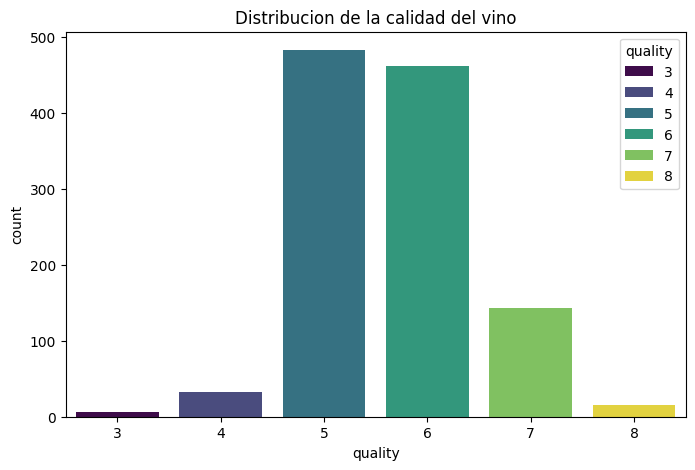

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quality', hue='quality', palette='viridis')
plt.title('Distribucion de la calidad del vino')
plt.show()

In [90]:
corr_quality = (df.corr(numeric_only=True)['quality'].drop(['quality', 'Id']).abs().sort_values(ascending=False))
top6 = corr_quality.head(6).index
print(top6)

Index(['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
       'total sulfur dioxide', 'density'],
      dtype='str')


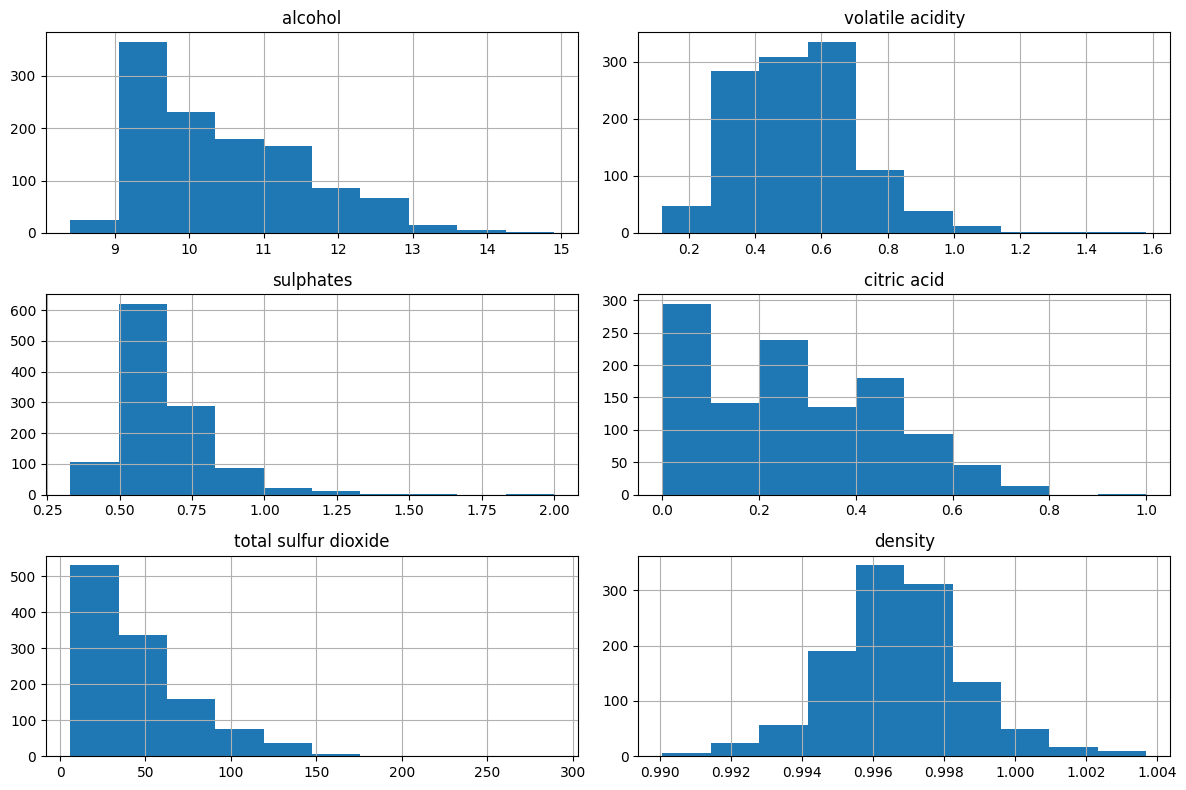

In [91]:
df[top6].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

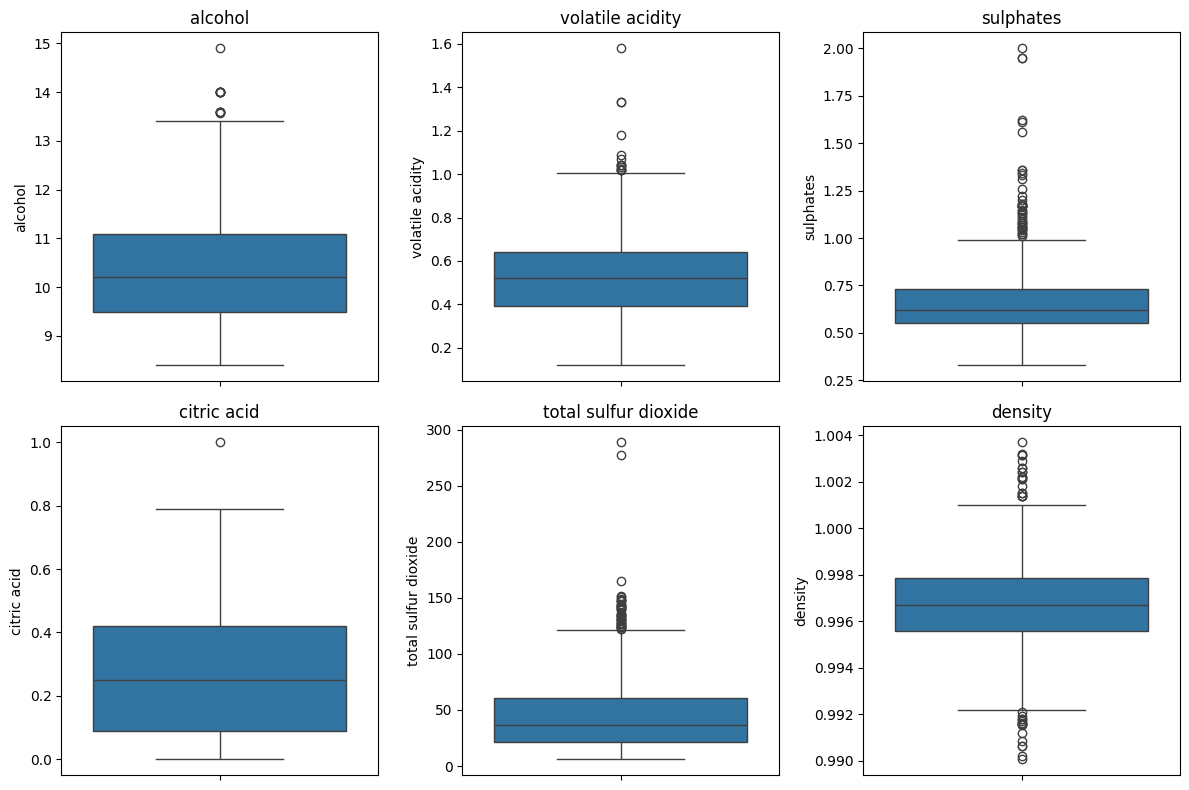

In [92]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, col in zip(axes.flatten(), top6):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

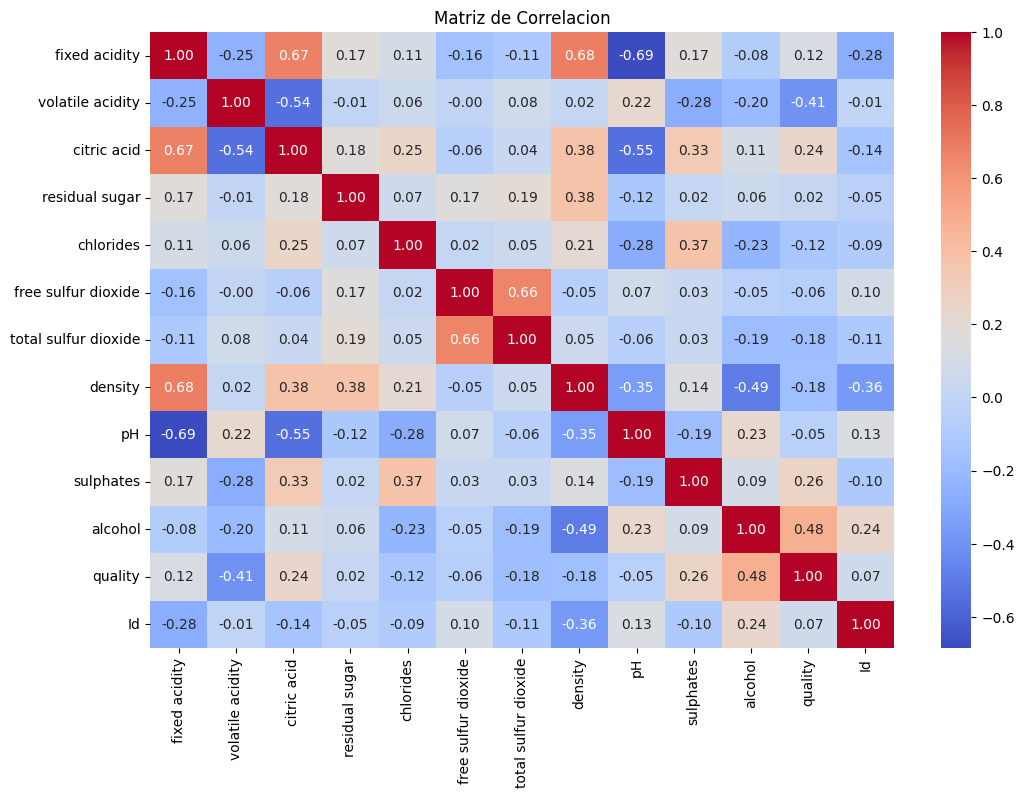

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion')
plt.show()

**Conclusiones EDA**

En la revision inicial podemos identificar que no contamos con duplicados ni nulos y el tipo de cada columna es correcto.

Para el grafico 1 la variable objetivo presenta una distribucion desbalanceada, con predominio de las categorias 5 y 6. Esto puede afectar el desempeño de los modelos de clasificacion, ya que tenderan a predecir con mayor frecuencia las clases mayoritarias y tendran dificultades para identificar correctamente las categorias extremas.

Para los histogramas decidi seleccionar el top6 de variables en relacion a la calidad de los vinos, podemos determinar lo siguente:
Alchohol, la graduacion alcohilica presenta una variabilidad moderada y podria ser una caracteristica relevante para explicar la calidad del vino.
La acidez volatil muestra cierta dispersion y presencia de valores elevados que podrian estar asociados a vinos de menor calidad.
Los sulfatos presentan una distribucion asimetrica con presencia de observaciones extremas, lo que sugiere una alta variabilidad entre las muestras analizadas.
El acido citrico muestra una distribucion heterogenea, indicando diferencias significativas en la composicion quimica de los vinos.
El dioxido de azufre total presenta una distribucion muy sesgada, evidenciando la existencia de vinos con niveles de conservacion significativamente superiores al promedio.
La densidad presenta una distribucion estable y homogenea, indicando poca variabilidad entre las muestras.

Para los boxplots, las variables quimicas muestran presencia de valores atipicos, especialmente en sulfatos y dioxido de azufre total. Sin embargo, estos valores podrian presentar caracteristicas reales de ciertos vinos y no necesariamente errores de medicion.

En la martiz existen algunas correlaciones moderadas entre variables quimicas, aunque no se observan niveles de multicolinealidad extremadamente altos. Las variables alcohol y acidez volatil son las que muestran la relacion mas fuerte con la calidad del vino.

El analisis exploratorio permitio identificar un conjunto de datos sin valores nulos ni registros duplicados, aunque con presencia de valores atipicos y un marcado desbalance en la variable objetivo. Las variables alcohol, acidez volatil, sulfatos y acido citrico presentan las asociaciones mas relavantes con la calidad del vino, por lo que se espera que tengan una contribucion importante en los modelos de clasificacion. Ademas, la distribucion de la calidad sugiere un problema de clasificacion multiclase desbalanceado, aspecto que debera considerarse durante la evaluacion de los modelos.

**Preprocesamiento**

In [64]:
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

In [65]:
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X, y)
importancias = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias)

alcohol                 0.149469
sulphates               0.120018
volatile acidity        0.104747
total sulfur dioxide    0.098143
density                 0.087986
chlorides               0.077026
pH                      0.076770
citric acid             0.074741
fixed acidity           0.073636
free sulfur dioxide     0.069901
residual sugar          0.067565
dtype: float64


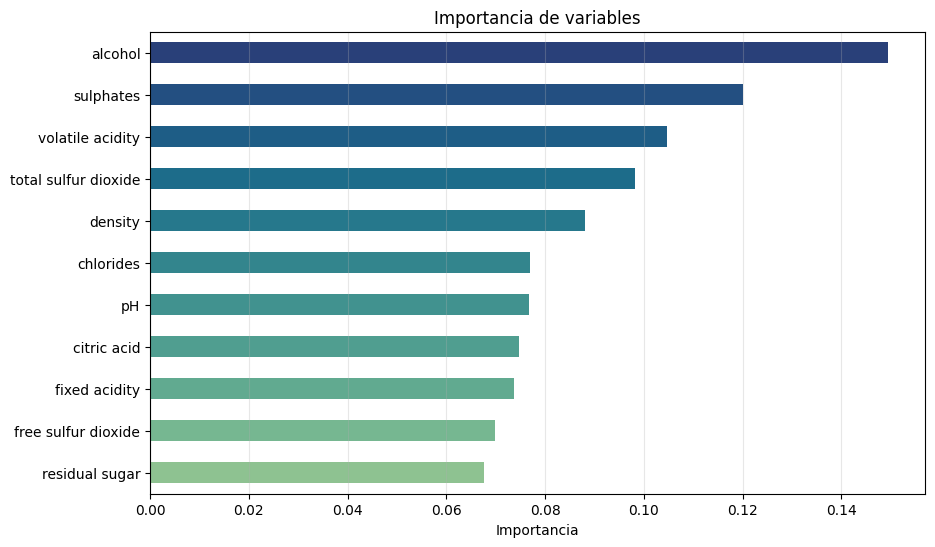

In [93]:
plt.figure(figsize=(10,6))
colores = sns.color_palette("crest", len(importancias))
importancias.sort_values().plot(kind='barh', color=colores)
plt.title('Importancia de variables')
plt.xlabel('Importancia')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

In [80]:
param_knn = {'n_neighbors':[3,5,7,9,11]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='f1_weighted')
grid_knn.fit(X_train_scaled, y_train)
knn = grid_knn.best_estimator_

In [81]:
param_rf = {'n_estimators':[100,200], 'max_depth':[5,10,None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='f1_weighted')
grid_rf.fit(X_train, y_train)
rf = grid_rf.best_estimator_

In [82]:
param_lr = {'C':[0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=5000), param_lr, cv=5, scoring='f1_weighted')
grid_lr.fit(X_train_scaled, y_train)
lr = grid_lr.best_estimator_

In [83]:
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred, average='weighted', zero_division=0))
    print('Recall:', recall_score(y_test, y_pred, average='weighted', zero_division=0))
    print('F1:', f1_score(y_test, y_pred, average='weighted', zero_division=0))
    print('\nReporte de clasificacion')
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()


KNN
Accuracy: 0.62882096069869
Precision: 0.5946006856939282
Recall: 0.62882096069869
F1: 0.6076687819339192

Reporte de clasificacion
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.68      0.73      0.71        97
           6       0.59      0.68      0.64        92
           7       0.53      0.34      0.42        29
           8       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.30      0.29      0.29       229
weighted avg       0.59      0.63      0.61       229



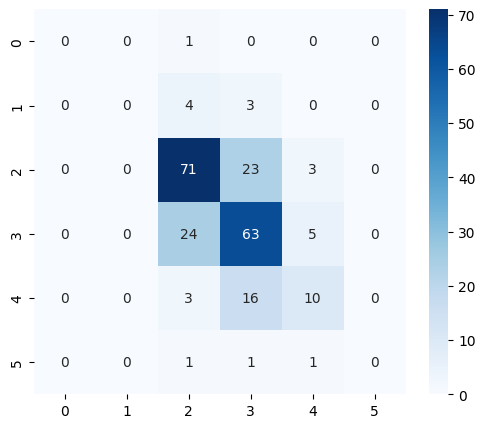

Random Forest
Accuracy: 0.6986899563318777
Precision: 0.6668160537838715
Recall: 0.6986899563318777
F1: 0.6776872165392472

Reporte de clasificacion
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.81      0.77        97
           6       0.66      0.73      0.69        92
           7       0.74      0.48      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.70       229
   macro avg       0.35      0.34      0.34       229
weighted avg       0.67      0.70      0.68       229



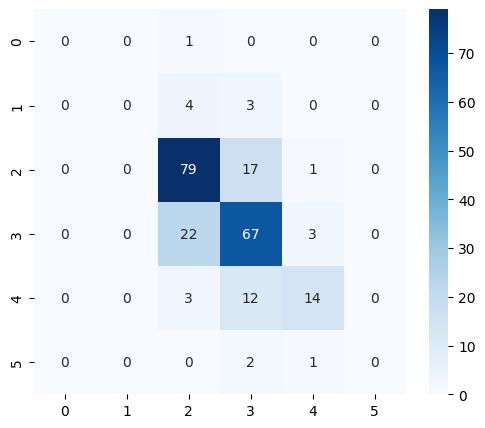

Logistic Regression
Accuracy: 0.6244541484716157
Precision: 0.5877153737415746
Recall: 0.6244541484716157
F1: 0.6036519509574253

Reporte de clasificacion
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.63      0.61        92
           7       0.43      0.31      0.36        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.29      0.29      0.28       229
weighted avg       0.59      0.62      0.60       229



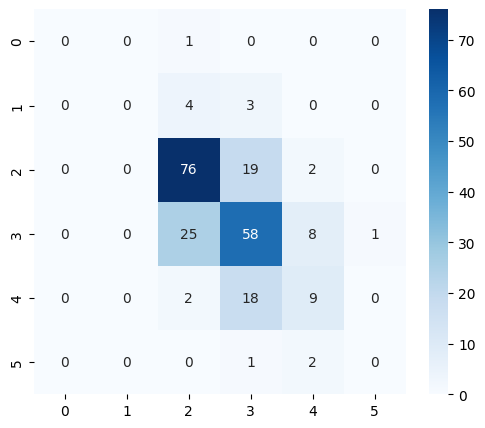

In [84]:
print('KNN')
evaluar_modelo(knn, X_test_scaled, y_test)

print('Random Forest')
evaluar_modelo(rf, X_test, y_test)

print('Logistic Regression')
evaluar_modelo(lr, X_test_scaled, y_test)

In [87]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))

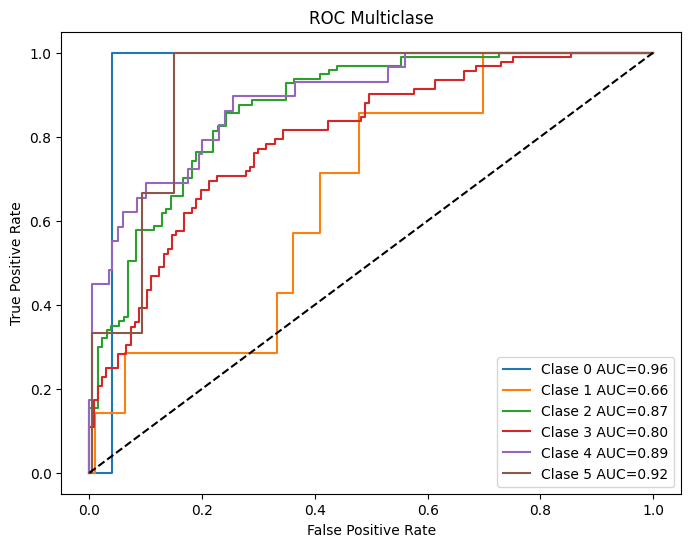

In [88]:
y_score = rf.predict_proba(X_test)
n_classes = y_test_bin.shape[1]
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {i} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Multiclase')
plt.legend()
plt.show()


In [89]:
resultado = pd.DataFrame({'Modelo': ['KNN', 'Random Forest', 'Logistic Regression'], 'Accuracy': [accuracy_score(y_test, knn.predict(X_test_scaled)),accuracy_score(y_test, rf.predict(X_test)), accuracy_score(y_test, lr.predict(X_test_scaled))], 'F1': [f1_score(y_test, knn.predict(X_test_scaled), average='weighted'), f1_score(y_test, rf.predict(X_test), average='weighted'), f1_score(y_test, lr.predict(X_test_scaled), average='weighted')]})
resultado.sort_values(by='F1', ascending=False)

,Modelo,Accuracy,F1
1,Random Forest,0.698690,0.677687
0,KNN,0.628821,0.607669
2,Logistic Regression,0.624454,0.603652


**Conclusiones finales**

El analisis de importancia de variables evidencio que el contenido de alcohol es el predictor mas relevante para estimar la calidad del vino, seguido por los sulfatos y la acidez volatil. Estos resultados son coherentes con el analisis de correlacion realizado previamente, donde alcohol presento la relacion positiva mas fuerte con la calidad y la acidez volatil mostro una relacion negativa moderada.

El escalamiento permitio que las variables se encontraran en una escala comparable, evitando que atributos con rangos mayores dominarian el proceso de aprendizaje de los algoritmos sensibles a la distancia.

La estratificacion permitio mantener la proporcial original de las clases de calidad de ambos conjuntos de datos, reduciendo el riesgo de sesgos durante la evaluacion de los modelos.

Modelado
KNN logro identificar adecuadamente las categorias predominantes del conjunto de datos, aunque presento dificultades para reconocer las clases minoritarias debido a su dependencia de la proximidad entre observaciones y al marcado desbalance presente en el dataset.

La regresion logistica obtuvo resultados comparables a KNN, mostrando una capacidad razonable para clasificar las categorias mas frecuentes. Sin embargo, su naturaleza lineal limita la captura de relaciones no lineales ente las variables fisicoquimicas y la calidad del vino.

Random Forest fue el modelo con mejor capacidad predictiva, logrando los mayores valores de accurancy y F1 Score. Su estructura basada en multiples arboles de decision permite capturar relaciones complejas entre variables quimicas y la calidad del vino, mejorando la capacidad de generalizacion respcto a los demas modelos evaluados.

El analisis de matrices de confusion muestra que los errores de clasificacion se concentran principalmente entre categorias adyacentes de calidad, lo que indica que los modelos son capaces de identificar niveles similares de calidad, aunque presentan dificultades para distinguir con precision los extremos de la escala.

La curva ROC multiclase muestra un capacidad de discriminacion satisfactoria para la mayoria de las categorias de calidad. Sin embargo, el reducido numero de observaciones en las clases extremas limita la robustez de estas metricas.

Conclusion comparativa
Random Forest obtuvo el mejor desempeño global, alcanzando una exactitud cercana al 70% y el mayor F1 Score entre los modelos ecaluados. KNN y Regresion logistica presentaron resultados similares, aunque inferiores al modelo basado en arboles. Esto sugiere que las relaciones entre las caracteristicas fisicoquimicas y la calidad del vino son principalmente no lineales, favoreciendo algoritmos capaces de modelar interacciones complejas entre variables.

El estudio permitio desarrollar y comparar distintos modelos de clasificacion para predecir la calidad del vino a partir de sus caracteristicas fisicoquimicas. El analisis exploratorio evidencio un conjunto de datos limpio, aunque con presencia de valores atipicos y un marcado desbalance en las clases de calidad. Tras el preprocesamiento y entrenamiento de los modelos, Random Forest demostro ser la alternativa mas efectiva, alcanzando el mejor equilibrio entre precision y capacidad de generalizacion. No obstante, todos los modelos mostraron dificultades para identificar correctamente las clases menos representadas.
